In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

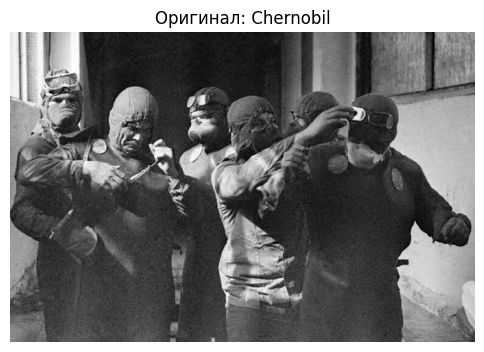

In [2]:
# Загрузка изображения и конвертация в градации серого
image_path = 'people_me.jpg'
image = cv2.imread(image_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.title("Оригинал: Chernobil")
plt.axis('off')
plt.show()

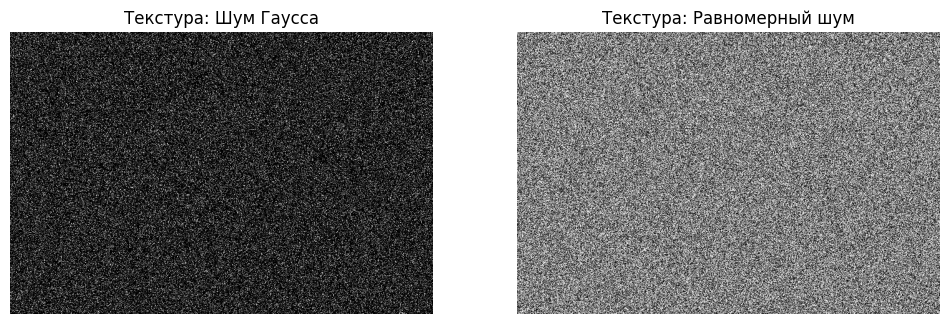

In [3]:
# 1 Шум Гаусса (нормальное распределение)
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

# 2 Равномерный шум (Uniform noise)
noise_uniform = np.zeros(image_gray.shape, np.uint8)
cv2.randu(noise_uniform, 0, 100) # Случайные значения от 0 до 100

# Вывод текстур чистого шума
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(noise_gauss, cmap="gray")
plt.title("Текстура: Шум Гаусса")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noise_uniform, cmap="gray")
plt.title("Текстура: Равномерный шум")
plt.axis('off')
plt.show()

In [4]:
# Накладываем шум на фото
image_noise_gauss = cv2.add(image_gray, noise_gauss)
image_noise_uniform = cv2.add(image_gray, noise_uniform)

# Фильтр Гаусса (ядро 5x5)
blur_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
blur_uniform = cv2.GaussianBlur(image_noise_uniform, (5, 5), 0)

#  Медианный фильтр (ядро 5)
median_gauss = cv2.medianBlur(image_noise_gauss, 5)
median_uniform = cv2.medianBlur(image_noise_uniform, 5)

#  Билатеральный фильтр (d=9, сигмы=75)
bilateral_gauss = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
bilateral_uniform = cv2.bilateralFilter(image_noise_uniform, 9, 75, 75)

#  Фильтр нелокальных средних NLM (h=30)
nlm_gauss = cv2.fastNlMeansDenoising(image_noise_gauss, None, 30, 7, 21)
nlm_uniform = cv2.fastNlMeansDenoising(image_noise_uniform, None, 30, 7, 21)

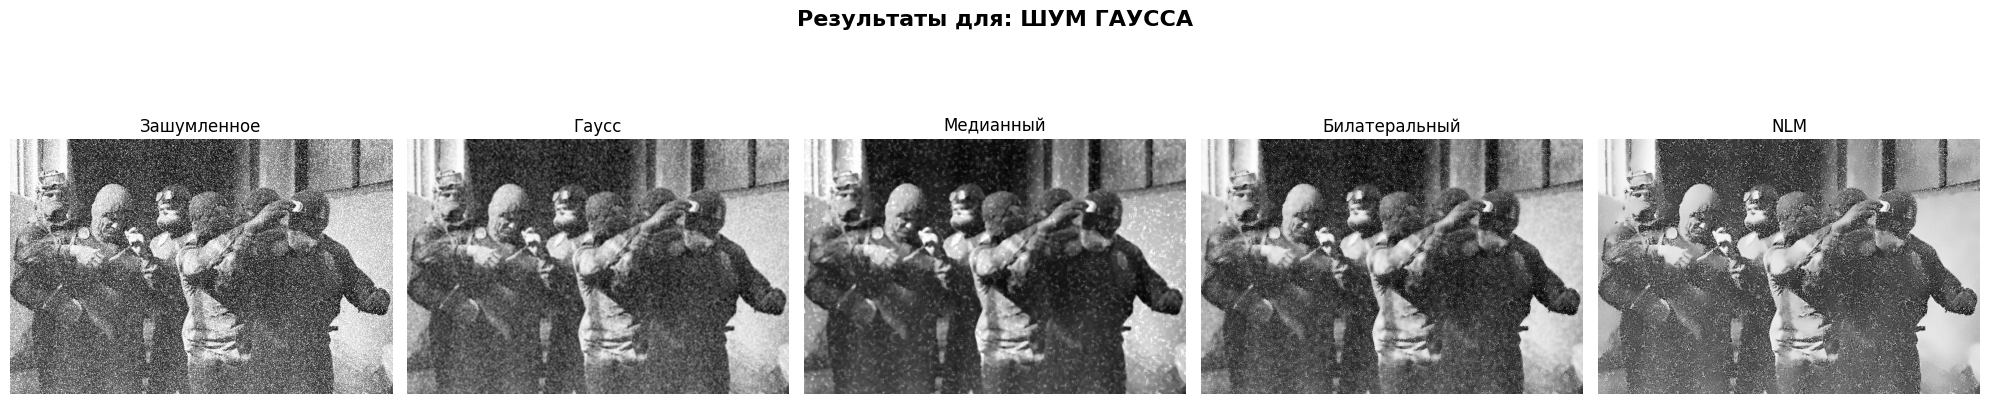

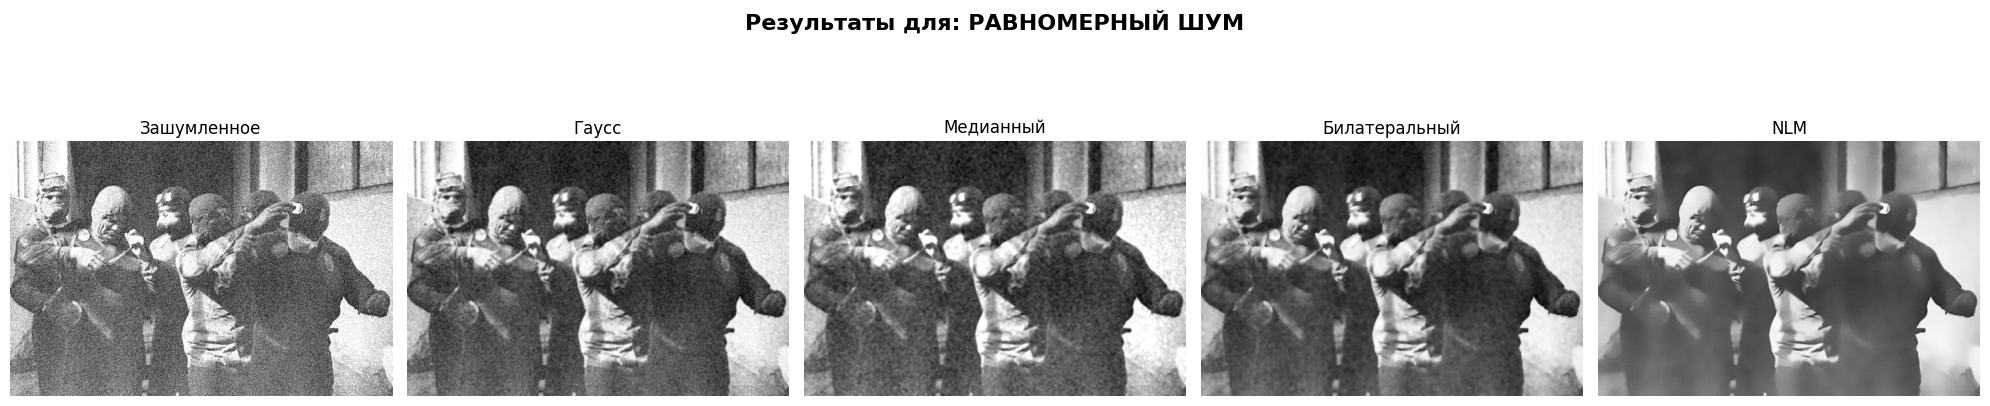

In [5]:
def show_filters(noisy_img, f_gauss, f_median, f_bilateral, f_nlm, noise_name):
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    fig.suptitle(f'Результаты для: {noise_name}', fontsize=16, fontweight='bold')

    images = [noisy_img, f_gauss, f_median, f_bilateral, f_nlm]
    titles = ['Зашумленное', 'Гаусс', 'Медианный', 'Билатеральный', 'NLM']

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Отрисовка
show_filters(image_noise_gauss, blur_gauss, median_gauss, bilateral_gauss, nlm_gauss, "ШУМ ГАУССА")
show_filters(image_noise_uniform, blur_uniform, median_uniform, bilateral_uniform, nlm_uniform, "РАВНОМЕРНЫЙ ШУМ")

Вывод по результатам фильтрации:

Для Равномерного шума: Лучший результат фильтрации показал Медианный фильтр. Он отлично удаляет черные и белые точки, сохраняя при этом резкость границ объектов изображения. Остальные фильтры лишь размывают точки, превращая их в пятна или оставляют такой же шум.

Для шума Гаусса: Лучший результат показал Медианный, так как он отлично восстанавливает однородные участки текстуры. Билатеральный фильтр также хорош.(на самом деле на каждой фотогрфии по-разному,это все индивидуально)